## 5. Clustering & Pattern Discovery <a id='5'></a>

### 5a. Station Clustering (Residential / Office / Tourist)

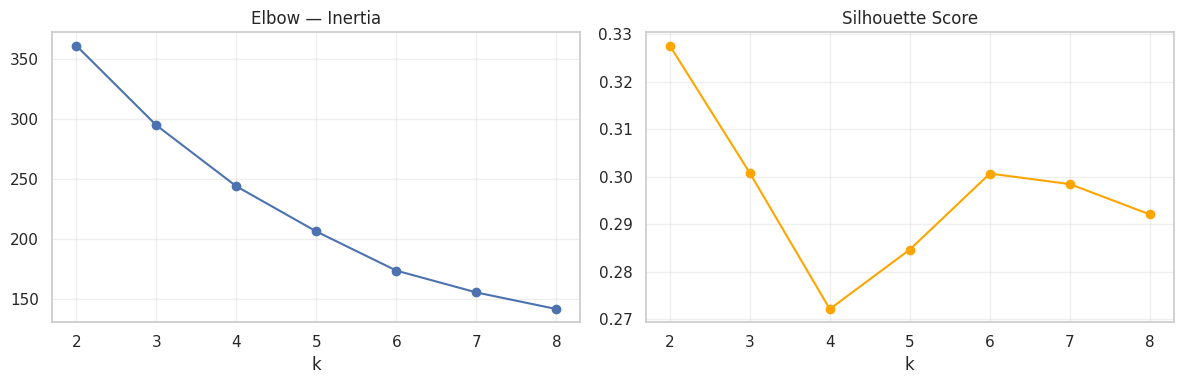

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Build per-station feature vector
sta = df.groupby('station_id').agg(
    lat           = ('lat','first'),
    lon           = ('lon','first'),
    name          = ('name','first'),
    capacity      = ('capacity','first'),
    avg_util      = ('utilisation','mean'),
    std_util      = ('utilisation','std'),
    morning_rush  = ('num_bikes_available', lambda x: x[df.loc[x.index,'hour'].isin([7,8,9])].mean()),
    evening_rush  = ('num_bikes_available', lambda x: x[df.loc[x.index,'hour'].isin([17,18,19])].mean()),
    weekend_avg   = ('num_bikes_available', lambda x: x[df.loc[x.index,'is_weekend']==1].mean()),
    weekday_avg   = ('num_bikes_available', lambda x: x[df.loc[x.index,'is_weekend']==0].mean()),
).reset_index()

sta['rush_diff']    = sta['morning_rush'] - sta['evening_rush']    # positive = bikes drain in morning
sta['we_wd_diff']   = sta['weekend_avg']  - sta['weekday_avg']     # positive = busier weekends
sta.dropna(inplace=True)

CLUS_FEATS = ['avg_util','std_util','rush_diff','we_wd_diff','capacity']
X_sta = sta[CLUS_FEATS].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sta)

# Elbow method
inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o'); axes[0].set_title('Elbow — Inertia'); axes[0].set_xlabel('k')
axes[1].plot(list(K_range), sils,     marker='o', color='orange'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

# Fit best k
BEST_K = 4
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
sta['cluster'] = km.fit_predict(X_scaled)

In [59]:
# Describe clusters
print('\nCluster profiles:')
print(sta.groupby('cluster')[CLUS_FEATS].mean().round(3).to_string())


Cluster profiles:
         avg_util  std_util  rush_diff  we_wd_diff  capacity
cluster                                                     
0           0.188     0.180      0.580      -1.268    33.828
1           0.542     0.300     -2.725       4.345    27.974
2           0.377     0.265     -2.662      -1.475    32.312
3           0.305     0.270      9.878      -4.187    37.250


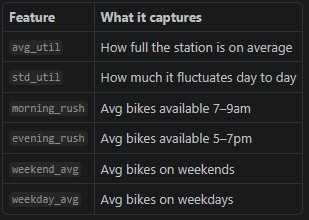

In [60]:
Image(filename='clust.jpg', width = 400, height = 200)

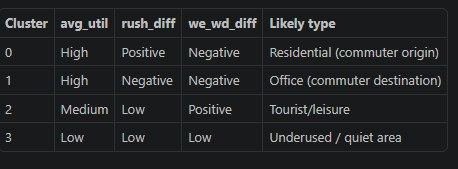

In [63]:
Image(filename='rotu.jpg', width = 400, height = 200)

In [64]:
import folium
from folium.plugins import MarkerCluster

cluster_colors = {0:'red', 1:'blue', 2:'green', 3:'purple', 4:'orange', 5:'darkred'}
cluster_labels = {0:'Cluster A', 1:'Cluster B', 2:'Cluster C', 3:'Cluster D'}

m = folium.Map(location=[53.3498, -6.2603], zoom_start=14, tiles='CartoDB positron')

for _, row in sta.iterrows():
    c = int(row['cluster'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8,
        color=cluster_colors.get(c,'gray'),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>Cluster: {cluster_labels.get(c,c)}<br>"
            f"Avg util: {row['avg_util']:.2f}<br>Rush diff: {row['rush_diff']:.2f}",
            max_width=250)
    ).add_to(m)

m.save('station_clusters_map.html')
print('Map saved → station_clusters_map.html')
m

Map saved → station_clusters_map.html


When a user clicks a station dot on the map, a small box appears showing:

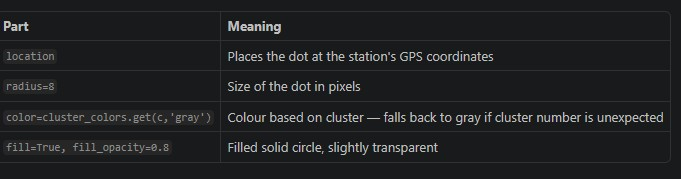

In [65]:
Image(filename='map.jpg', width = 600, height = 400)

Each station dot on the Dublin map is coloured by its cluster type. By looking at the geographic pattern of colours you can visually confirm whether the clustering makes sense.Example you would expect office clusters concentrated in the city centre, residential clusters further out, tourist clusters near landmarks like the Liffey or St Stephen's Green.

### 5b. Temporal Demand Pattern Clustering

In [66]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Build hourly availability profile per station (24-dim vector)
hourly_profile = (df.groupby(['station_id','hour'])['utilisation']
                    .mean().unstack('hour').fillna(0))

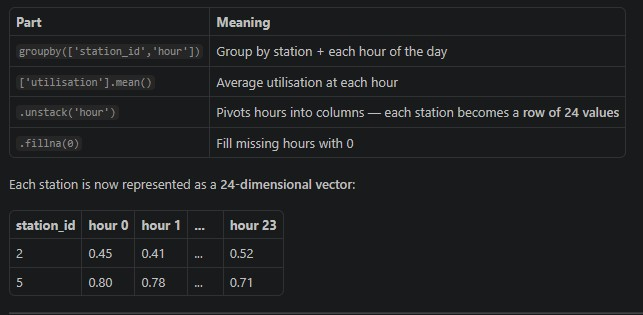

In [67]:
Image(filename='hour.jpg', width = 600, height = 400)

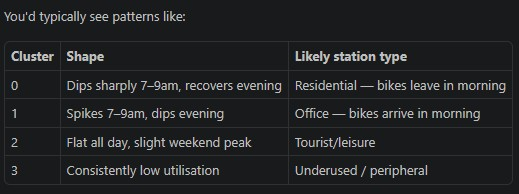

In [68]:
Image(filename='four.jpg', width = 400, height = 200)

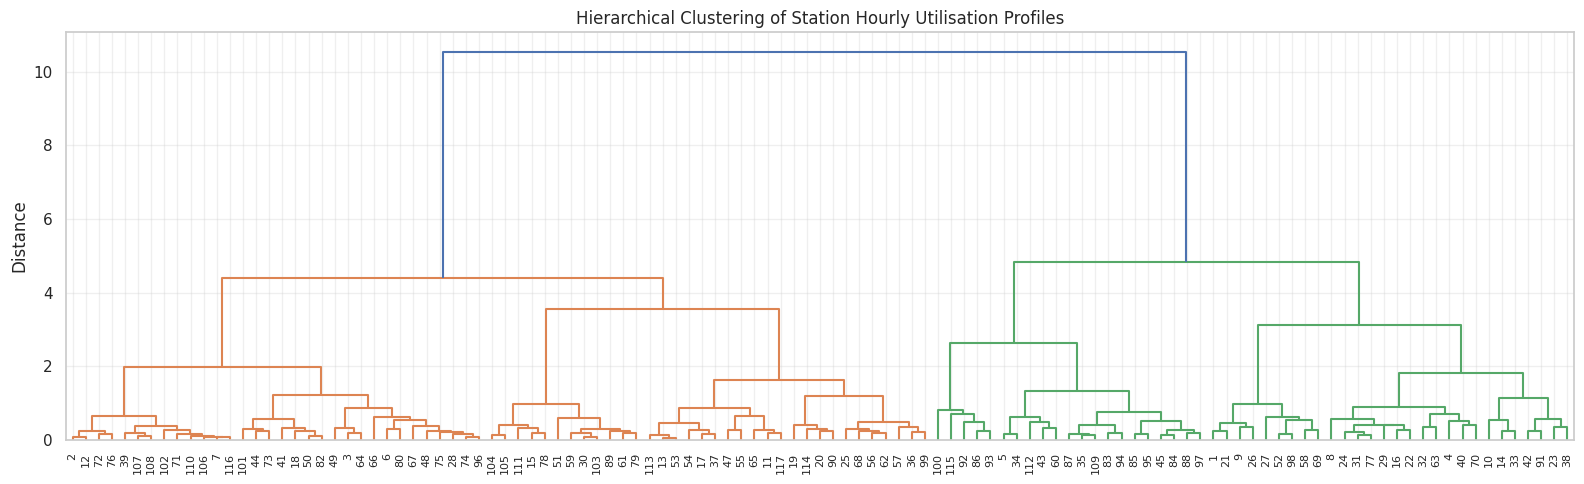

In [69]:
# Hierarchical clustering
Z = linkage(hourly_profile.values, method='ward')
plt.figure(figsize=(16, 5))
dendrogram(Z, labels=hourly_profile.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering of Station Hourly Utilisation Profiles')
plt.ylabel('Distance'); plt.tight_layout(); plt.show()

In [70]:
# Assign 4 temporal clusters
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
hourly_profile['temporal_cluster'] = agg.fit_predict(hourly_profile.drop(columns=['temporal_cluster'], errors='ignore'))

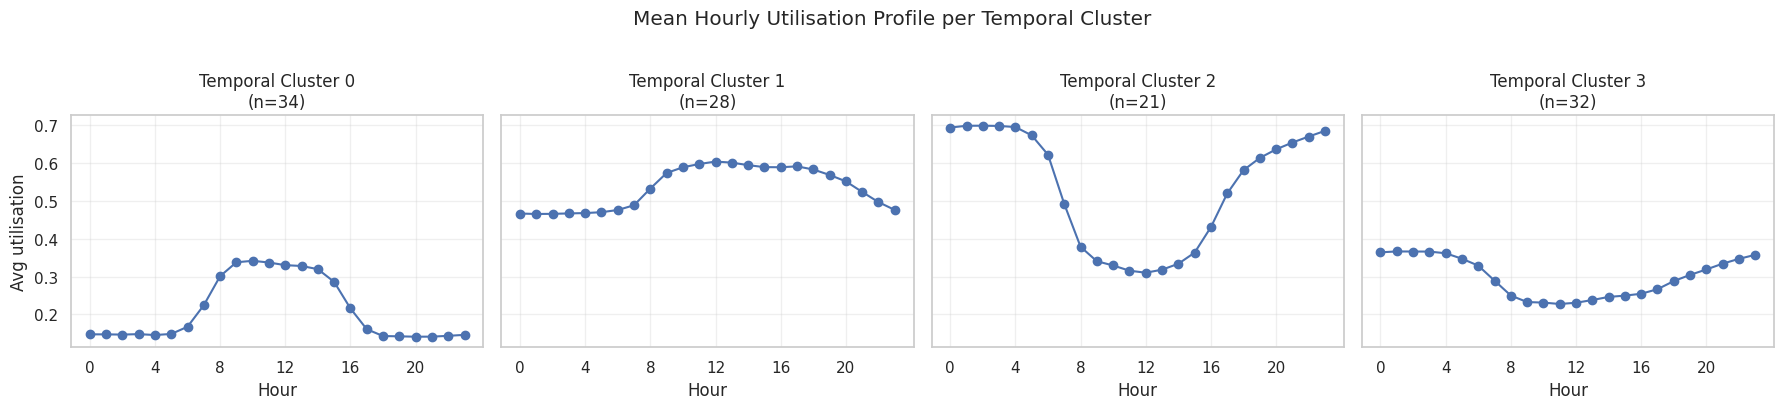

In [71]:
# Plot mean profile per cluster
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for cl, ax in enumerate(axes):
    mask = hourly_profile['temporal_cluster'] == cl
    mean_profile = hourly_profile.loc[mask, range(24)].mean()
    ax.plot(mean_profile.index, mean_profile.values, marker='o')
    ax.set_title(f'Temporal Cluster {cl}\n(n={mask.sum()})')
    ax.set_xlabel('Hour'); ax.set_xticks(range(0,24,4))
    if cl == 0: ax.set_ylabel('Avg utilisation')
plt.suptitle('Mean Hourly Utilisation Profile per Temporal Cluster', y=1.02)
plt.tight_layout(); plt.show()

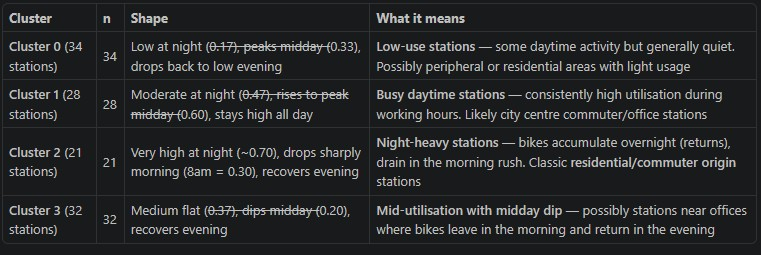

In [73]:
Image(filename='four1.jpg', width = 500, height = 300)

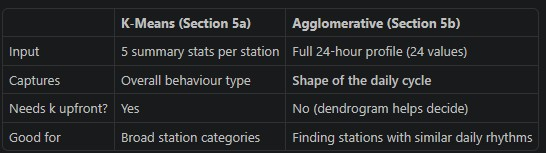

In [74]:
Image(filename='daily.jpg', width = 400, height = 200)

### 5c. Heatmaps of Demand

In [75]:
from folium.plugins import HeatMap

# High-demand = low bike availability (people taking bikes)
# Use inverse of utilisation as demand proxy
df['demand_proxy'] = 1 - df['utilisation'].clip(0, 1)

# Morning rush heatmap
morning_data = df[df['hour'].isin([7,8,9])]
heat_data = morning_data.groupby('station_id').agg(
    lat=('lat','first'), lon=('lon','first'),
    weight=('demand_proxy','mean')
).dropna()

m2 = folium.Map(location=[53.3498, -6.2603], zoom_start=14, tiles='CartoDB dark_matter')
HeatMap(heat_data[['lat','lon','weight']].values.tolist(),
        radius=20, blur=15, max_zoom=13).add_to(m2)
m2.save('demand_heatmap_morning.html')
print('Morning rush heatmap saved → demand_heatmap_morning.html')
m2

Morning rush heatmap saved → demand_heatmap_morning.html


## 6. Anomaly Detection <a id='6'></a>

### 6a. Unusual Demand Spike Detection

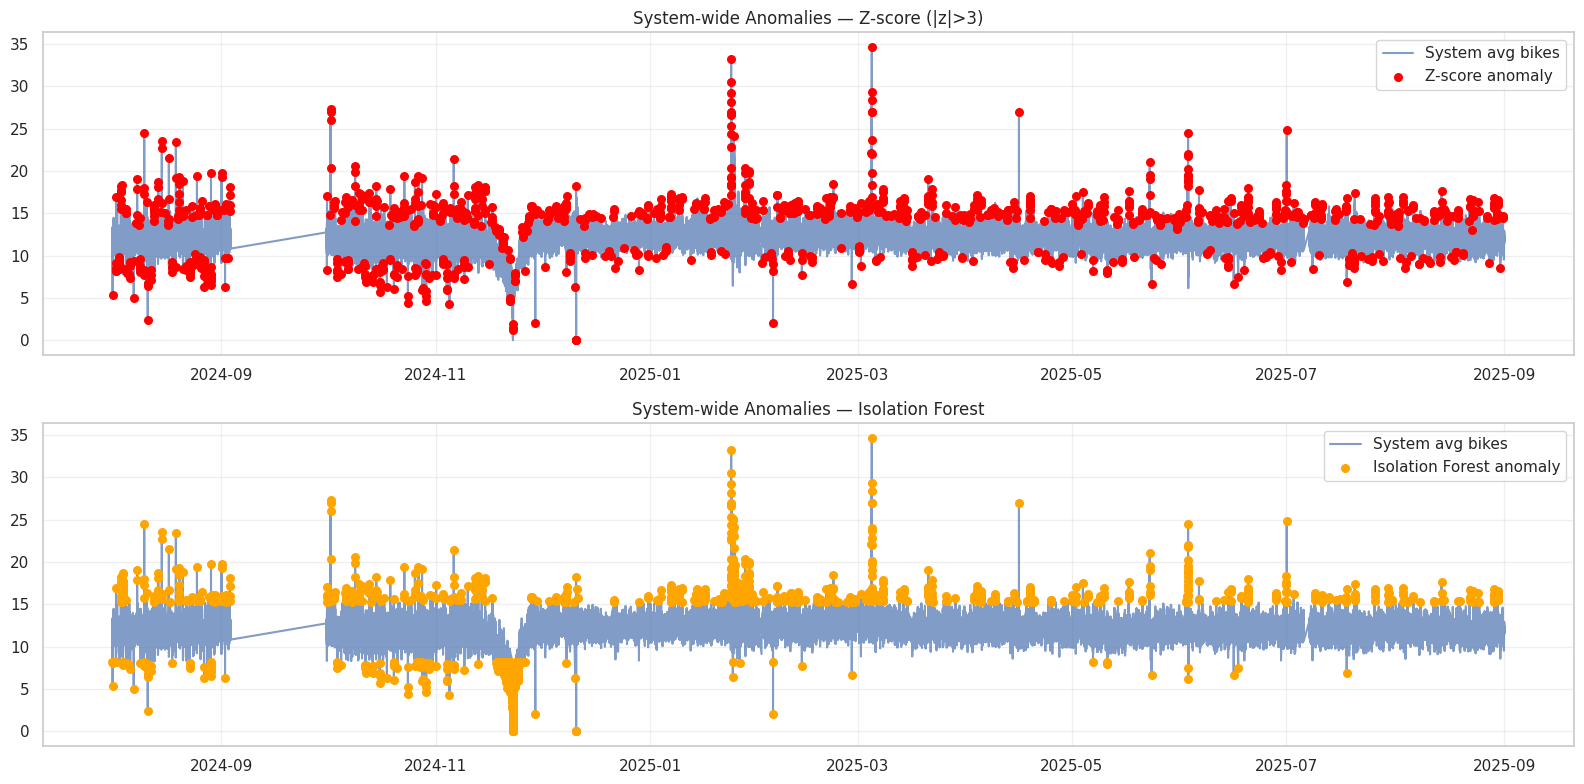

Z-score anomalies: 1270
Isolation Forest anomalies: 2085


In [76]:
from sklearn.ensemble import IsolationForest

# System-wide hourly average — detect days with anomalous usage
hourly_sys = (df.groupby('last_reported')['num_bikes_available']
                .mean().reset_index(name='sys_avg'))
hourly_sys = hourly_sys.set_index('last_reported').sort_index()

# Rolling Z-score anomaly
hourly_sys['roll_mean'] = hourly_sys['sys_avg'].rolling(144, min_periods=1).mean()  # ~24h
hourly_sys['roll_std']  = hourly_sys['sys_avg'].rolling(144, min_periods=1).std()
hourly_sys['z_score']   = (hourly_sys['sys_avg'] - hourly_sys['roll_mean']) / hourly_sys['roll_std'].replace(0, np.nan)
hourly_sys['anomaly_z'] = hourly_sys['z_score'].abs() > 3

# Isolation Forest
X_iso = hourly_sys[['sys_avg']].fillna(method='ffill').values
iso = IsolationForest(contamination=0.02, random_state=42)
hourly_sys['anomaly_if'] = iso.fit_predict(X_iso) == -1

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(hourly_sys.index, hourly_sys['sys_avg'], alpha=0.7, label='System avg bikes')
anom_z = hourly_sys[hourly_sys['anomaly_z']]
axes[0].scatter(anom_z.index, anom_z['sys_avg'], color='red', s=30, zorder=5, label='Z-score anomaly')
axes[0].set_title('System-wide Anomalies — Z-score (|z|>3)'); axes[0].legend()

axes[1].plot(hourly_sys.index, hourly_sys['sys_avg'], alpha=0.7, label='System avg bikes')
anom_if = hourly_sys[hourly_sys['anomaly_if']]
axes[1].scatter(anom_if.index, anom_if['sys_avg'], color='orange', s=30, zorder=5, label='Isolation Forest anomaly')
axes[1].set_title('System-wide Anomalies — Isolation Forest'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Z-score anomalies: {hourly_sys["anomaly_z"].sum()}')
print(f'Isolation Forest anomalies: {hourly_sys["anomaly_if"].sum()}')

### 6b. Station Malfunction Detection

Suspicious stations: 1
 station_id             name  pct_zero_bikes  pct_full_docks  pct_not_renting  std_bikes
         51 YORK STREET WEST        0.902294        0.894168         0.001177   4.395724


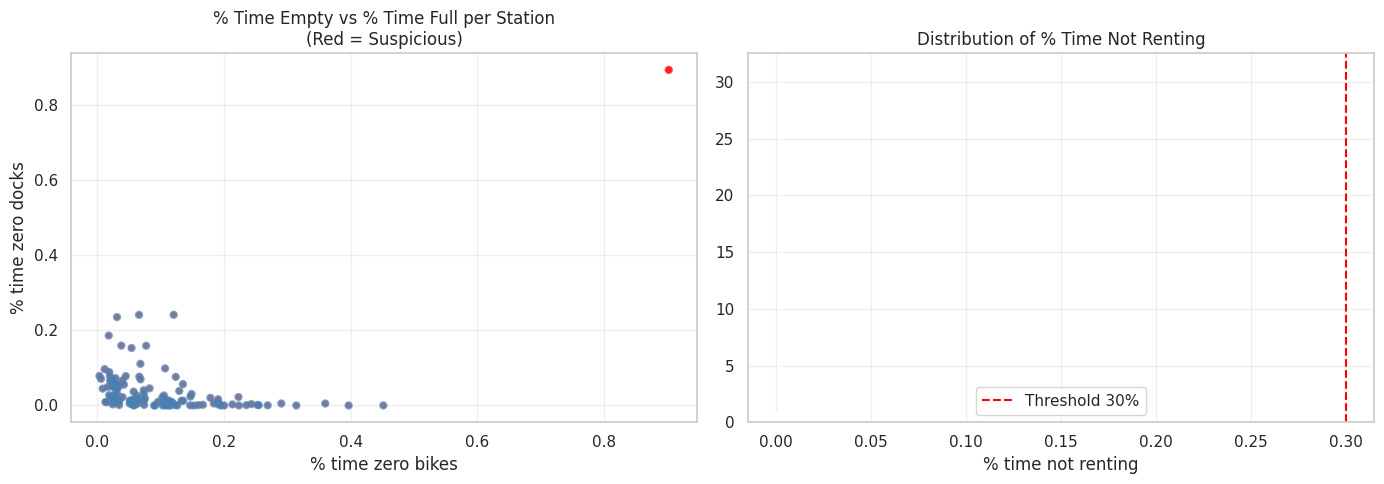

In [77]:
# Suspicious patterns: station always empty, always full, or is_renting=False for long periods
sta_diag = df.groupby('station_id').agg(
    name             = ('name','first'),
    pct_zero_bikes   = ('num_bikes_available', lambda x: (x==0).mean()),
    pct_full_docks   = ('num_docks_available', lambda x: (x==0).mean()),
    pct_not_renting  = ('is_renting',          lambda x: (~x).mean()),
    pct_not_returning= ('is_returning',         lambda x: (~x).mean()),
    std_bikes        = ('num_bikes_available','std'),
    n_records        = ('last_reported','count')
).reset_index()

# Flag suspicious stations
sta_diag['suspicious'] = (
    (sta_diag['pct_zero_bikes'] > 0.5) |
    (sta_diag['pct_full_docks'] > 0.5) |
    (sta_diag['pct_not_renting'] > 0.3) |
    (sta_diag['std_bikes'] < 0.5)
)

suspicious_stations = sta_diag[sta_diag['suspicious']].sort_values('pct_zero_bikes', ascending=False)
print(f'Suspicious stations: {len(suspicious_stations)}')
print(suspicious_stations[['station_id','name','pct_zero_bikes','pct_full_docks',
                             'pct_not_renting','std_bikes']].head(15).to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sta_diag.plot.scatter('pct_zero_bikes','pct_full_docks',
    c='suspicious'.replace('suspicious', 'red'), colormap=None, ax=axes[0],
    alpha=0.6, edgecolors='none')

colors = sta_diag['suspicious'].map({True:'red', False:'steelblue'})
axes[0].scatter(sta_diag['pct_zero_bikes'], sta_diag['pct_full_docks'],
                c=colors, alpha=0.7, edgecolors='none')
axes[0].set_title('% Time Empty vs % Time Full per Station\n(Red = Suspicious)')
axes[0].set_xlabel('% time zero bikes'); axes[0].set_ylabel('% time zero docks')

sta_diag['pct_not_renting'].hist(bins=30, ax=axes[1], edgecolor='white')
axes[1].axvline(0.3, color='red', linestyle='--', label='Threshold 30%')
axes[1].set_title('Distribution of % Time Not Renting')
axes[1].set_xlabel('% time not renting'); axes[1].legend()

plt.tight_layout(); plt.show()

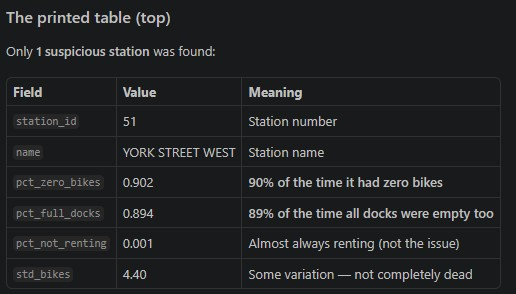

In [78]:
Image(filename='sus.jpg', width = 400, height = 200)

## 7. Recommender & Optimisation <a id='7'></a>

### 7a. Next-station Recommender

In [79]:
from sklearn.metrics.pairwise import haversine_distances
from math import radians

In [80]:
# Build latest snapshot
latest = df.sort_values('last_reported').groupby('station_id').last().reset_index()
latest = latest[['station_id','name','lat','lon','num_bikes_available',
                  'num_docks_available','is_renting','is_returning','capacity']]

def recommend_stations(current_station_id, need='bike', n_results=5):
    """
    Recommend nearest stations that have bikes (need='bike')
    or free docks (need='dock').
    """
    origin = latest[latest['station_id'] == current_station_id]
    if origin.empty:
        return pd.DataFrame({'error': ['Station not found']})

    ox, oy = radians(origin.iloc[0]['lat']), radians(origin.iloc[0]['lon'])

    candidates = latest[latest['station_id'] != current_station_id].copy()
    if need == 'bike':
        candidates = candidates[(candidates['num_bikes_available'] >= 2) &
                                  (candidates['is_renting'] == True)]
    else:
        candidates = candidates[(candidates['num_docks_available'] >= 2) &
                                  (candidates['is_returning'] == True)]

    coords = candidates[['lat','lon']].apply(lambda r: [radians(r['lat']), radians(r['lon'])], axis=1)
    dists  = [haversine_distances([[ox, oy]], [c])[0][0] * 6371000 for c in coords]  # metres
    candidates['dist_m'] = dists

    col = 'num_bikes_available' if need == 'bike' else 'num_docks_available'
    result = (candidates.sort_values('dist_m')
                        .head(n_results)
                        [['station_id','name','dist_m', col, 'lat','lon']])
    return result

# Example: looking for a bike near station 1
example_id = latest['station_id'].iloc[0]
print(f'Looking for BIKES near station {example_id} ({latest[latest["station_id"]==example_id]["name"].values[0]}):')
print(recommend_stations(example_id, need='bike').to_string(index=False))

print(f'\nLooking for FREE DOCKS near station {example_id}:')
print(recommend_stations(example_id, need='dock').to_string(index=False))

Looking for BIKES near station 1 (CLARENDON ROW):
 station_id                      name     dist_m  num_bikes_available       lat       lon
         52          YORK STREET EAST 243.547627                   18 53.338757 -6.262003
         17               GOLDEN LANE 347.569342                    9 53.340800 -6.267732
         98    FREDERICK STREET SOUTH 380.621246                   22 53.341515 -6.256853
         37 ST. STEPHEN'S GREEN SOUTH 383.236806                    7 53.337494 -6.261990
         14       FOWNES STREET UPPER 412.922910                   16 53.344604 -6.263371

Looking for FREE DOCKS near station 1:
 station_id                   name     dist_m  num_docks_available       lat       lon
         52       YORK STREET EAST 243.547627                   14 53.338757 -6.262003
          9       EXCHEQUER STREET 244.848530                   24 53.343033 -6.263578
         27      MOLESWORTH STREET 293.834513                   20 53.341290 -6.258117
         17           

In [81]:
# Visualise recommendation on a map
recs = recommend_stations(example_id, need='bike')
origin_row = latest[latest['station_id'] == example_id].iloc[0]

m3 = folium.Map(location=[origin_row['lat'], origin_row['lon']], zoom_start=15, tiles='CartoDB positron')

folium.Marker([origin_row['lat'], origin_row['lon']],
              popup=f"<b>YOU ARE HERE</b><br>{origin_row['name']}",
              icon=folium.Icon(color='red', icon='user', prefix='fa')).add_to(m3)

for i, row in recs.iterrows():
    folium.Marker([row['lat'], row['lon']],
                  popup=f"#{i+1} {row['name']}<br>{int(row['num_bikes_available'])} bikes<br>{int(row['dist_m'])}m away",
                  icon=folium.Icon(color='green', icon='bicycle', prefix='fa')).add_to(m3)
    folium.PolyLine([[origin_row['lat'], origin_row['lon']], [row['lat'], row['lon']]],
                    color='blue', weight=2, opacity=0.6).add_to(m3)

m3.save('recommender_map.html')
print('Saved → recommender_map.html')
m3

Saved → recommender_map.html


## 8. Geospatial & Network Analysis <a id='8'></a>

### 8a. Coverage Gap Analysis (Voronoi)

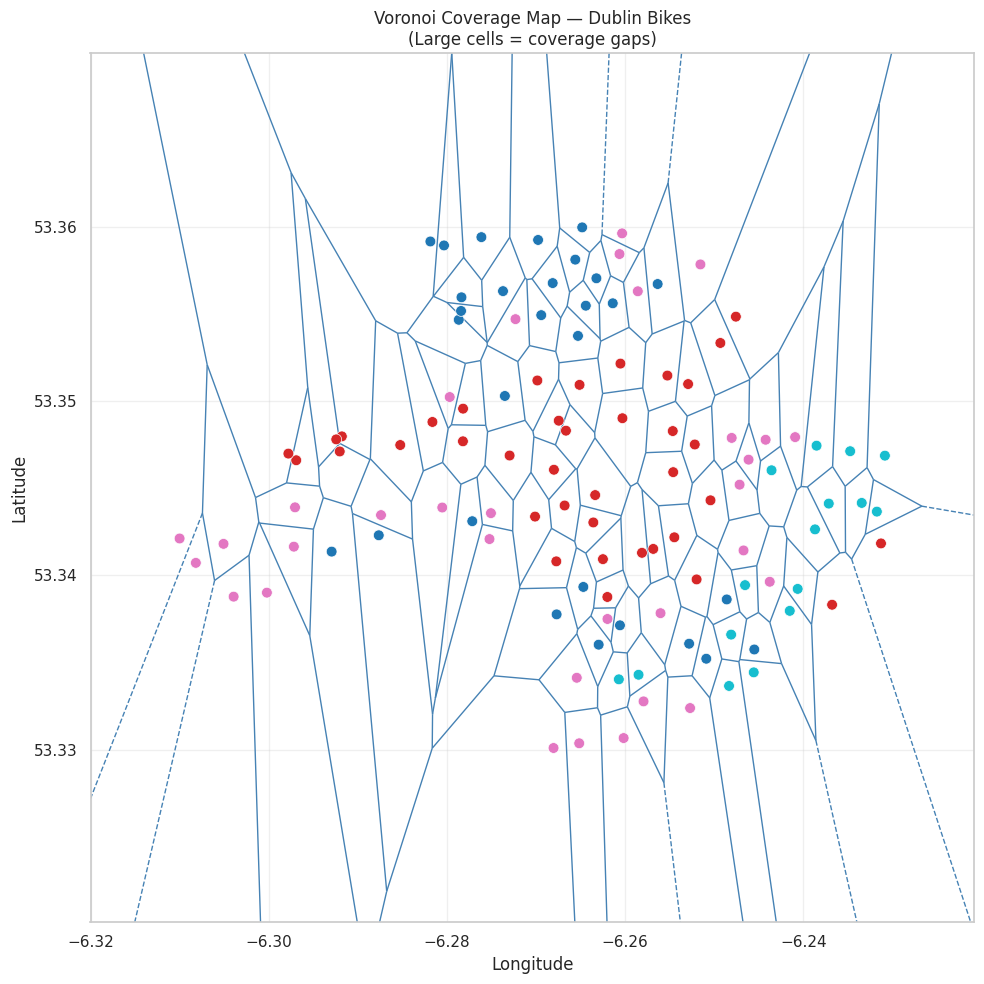

In [82]:
from scipy.spatial import Voronoi, voronoi_plot_2d

coords = sta[['lon','lat']].values
vor = Voronoi(coords)

fig, ax = plt.subplots(figsize=(10, 10))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='steelblue', line_width=1, point_size=5)
ax.scatter(sta['lon'], sta['lat'], c=sta['cluster'].astype(int),
           cmap='tab10', s=60, zorder=5, edgecolors='white', linewidths=0.5)

# Annotate large Voronoi cells (gaps)
ax.set_xlim(sta['lon'].min()-0.01, sta['lon'].max()+0.01)
ax.set_ylim(sta['lat'].min()-0.01, sta['lat'].max()+0.01)
ax.set_title('Voronoi Coverage Map — Dublin Bikes\n(Large cells = coverage gaps)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show() #If a station has a huge polygon: There are very few nearby stations

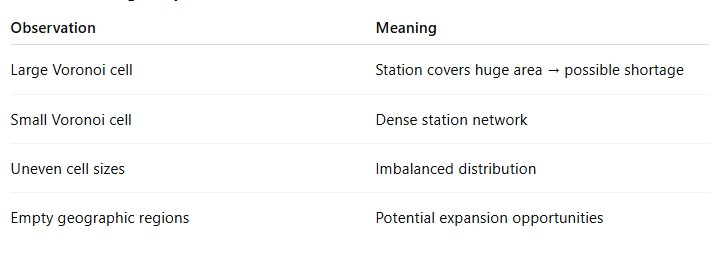

In [83]:
Image(filename='Voron.jpg', width = 800, height = 500)

### 8b. Interactive Station Dashboard Map

In [84]:
latest_merged = latest.merge(sta[['station_id','cluster','avg_util','rush_diff']], on='station_id', how='left')

fig_map = px.scatter_mapbox(
    latest_merged,
    lat='lat', lon='lon',
    color='num_bikes_available',
    size='capacity',
    hover_name='name',
    hover_data={'num_bikes_available':True, 'num_docks_available':True,
                'capacity':True, 'avg_util':':.2f', 'cluster':True},
    color_continuous_scale='RdYlGn',
    range_color=[0, latest_merged['capacity'].max()],
    mapbox_style='carto-positron',
    zoom=12.5,
    center={'lat':53.3498,'lon':-6.2603},
    title='Dublin Bikes — Latest Station Status'
)
fig_map.update_layout(height=600, coloraxis_colorbar_title='Bikes available')
fig_map.show()

In [85]:
fig_map.write_html("map.html")

Result: An interactive map where you can visually see at a glance which stations are empty (red), partially stocked (yellow), or full (green), with dot size showing how large the station is, and hover tooltips giving the full detail including cluster group and utilisation stats.

## 9. Operational Analytics <a id='9'></a>

### 9a. Utilisation Rate Analysis

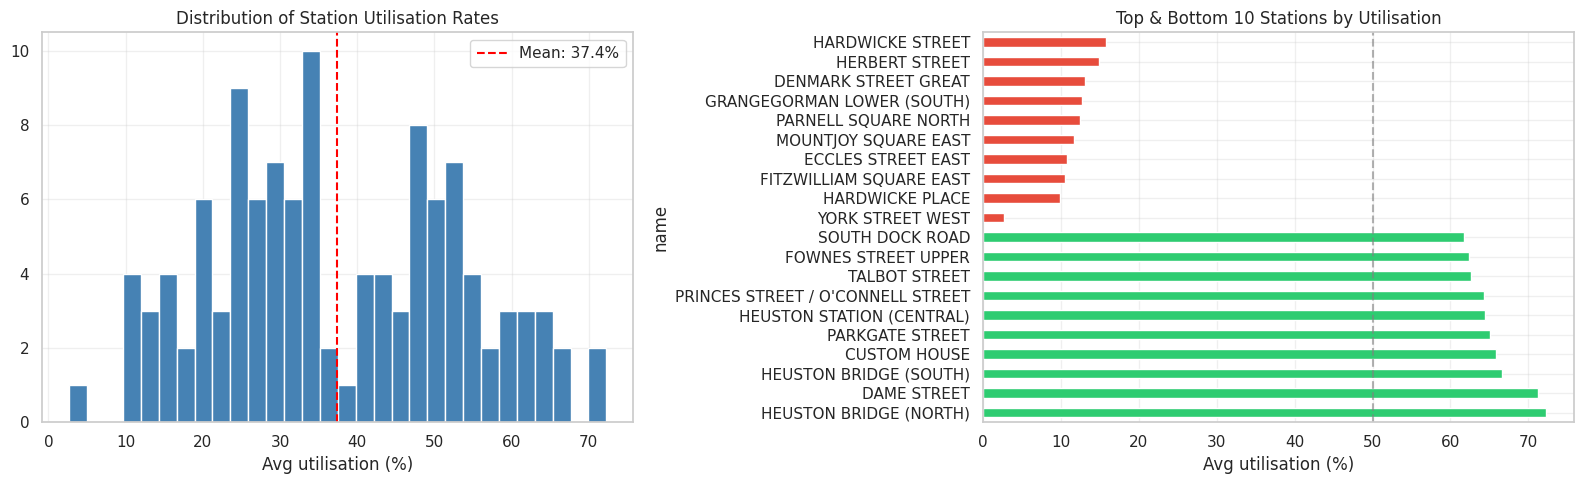

In [86]:
util_sta = sta[['station_id','name','lat','lon','avg_util','std_util','capacity']].copy()
util_sta['util_pct'] = util_sta['avg_util'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
util_sta['util_pct'].hist(bins=30, ax=axes[0], edgecolor='white', color='steelblue')
axes[0].axvline(util_sta['util_pct'].mean(), color='red', linestyle='--',
                label=f'Mean: {util_sta["util_pct"].mean():.1f}%')
axes[0].set_title('Distribution of Station Utilisation Rates')
axes[0].set_xlabel('Avg utilisation (%)')
axes[0].legend()

# Top/bottom stations
top10 = util_sta.nlargest(10, 'util_pct')[['name','util_pct']]
bot10 = util_sta.nsmallest(10, 'util_pct')[['name','util_pct']]
combined = pd.concat([top10.assign(group='High'), bot10.assign(group='Low')])
colors = combined['group'].map({'High':'#2ecc71','Low':'#e74c3c'})
combined.plot.barh(x='name', y='util_pct', ax=axes[1], color=colors, legend=False)
axes[1].set_title('Top & Bottom 10 Stations by Utilisation')
axes[1].set_xlabel('Avg utilisation (%)')
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

### 9b. Rebalancing Optimisation

Total surplus bikes : 261
Total deficit bikes : 732


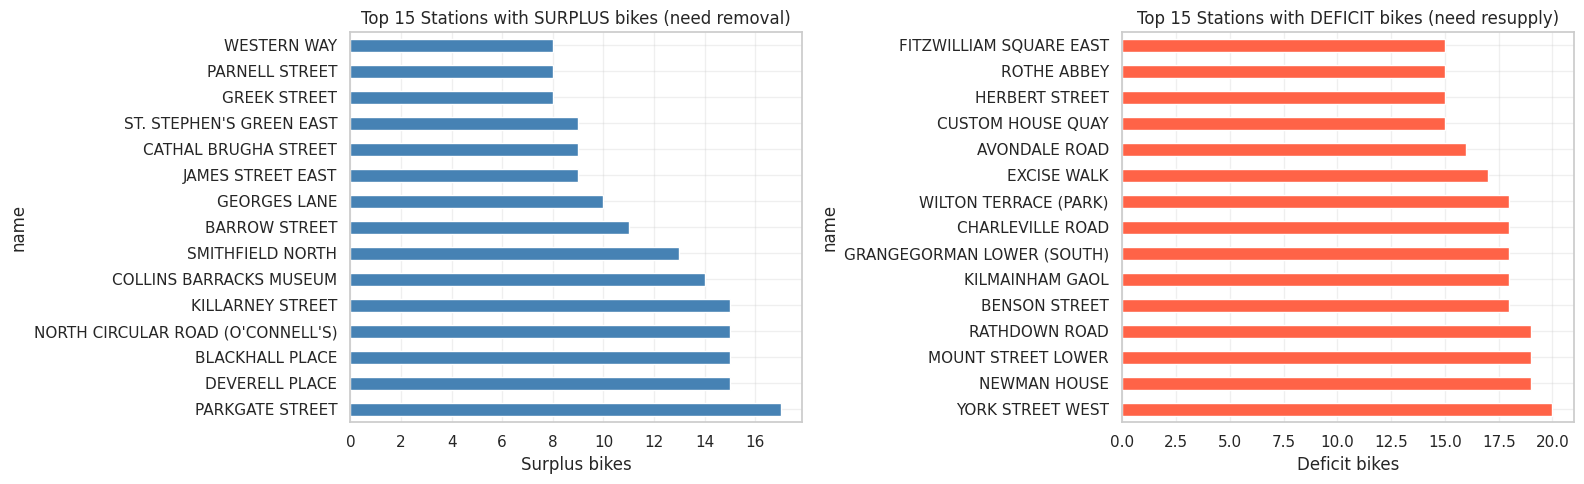


Stations needing rebalancing: 35 surplus, 75 deficit


In [87]:
# Identify rebalancing needs: stations with surplus vs deficit at each time window
# Target: every station at ~50% utilisation

TARGET_UTIL = 0.5
rebal = latest_merged.copy()
rebal['ideal_bikes'] = (rebal['capacity'] * TARGET_UTIL).round().astype(int)
rebal['surplus']     = (rebal['num_bikes_available'] - rebal['ideal_bikes']).clip(lower=0)
rebal['deficit']     = (rebal['ideal_bikes'] - rebal['num_bikes_available']).clip(lower=0)

print(f'Total surplus bikes : {rebal["surplus"].sum()}')
print(f'Total deficit bikes : {rebal["deficit"].sum()}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_surplus = rebal.nlargest(15,'surplus')[['name','surplus']]
top_surplus.plot.barh(x='name', y='surplus', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Top 15 Stations with SURPLUS bikes (need removal)')
axes[0].set_xlabel('Surplus bikes')

top_deficit = rebal.nlargest(15,'deficit')[['name','deficit']]
top_deficit.plot.barh(x='name', y='deficit', ax=axes[1], color='tomato', legend=False)
axes[1].set_title('Top 15 Stations with DEFICIT bikes (need resupply)')
axes[1].set_xlabel('Deficit bikes')

plt.tight_layout(); plt.show()

# Nearest-neighbour matching: pair surplus → deficit
surplus_sta = rebal[rebal['surplus'] > 0][['station_id','name','lat','lon','surplus']].copy()
deficit_sta = rebal[rebal['deficit'] > 0][['station_id','name','lat','lon','deficit']].copy()

print(f'\nStations needing rebalancing: {len(surplus_sta)} surplus, {len(deficit_sta)} deficit')

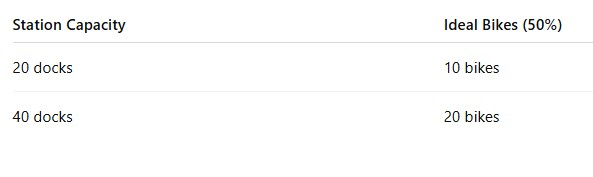

In [88]:
Image(filename='reb.jpg', width = 400, height = 200)

### 9c. Capacity Planning


Capacity planning summary:
recommendation
OK                   93
Reduce / relocate    17
Expand capacity       5


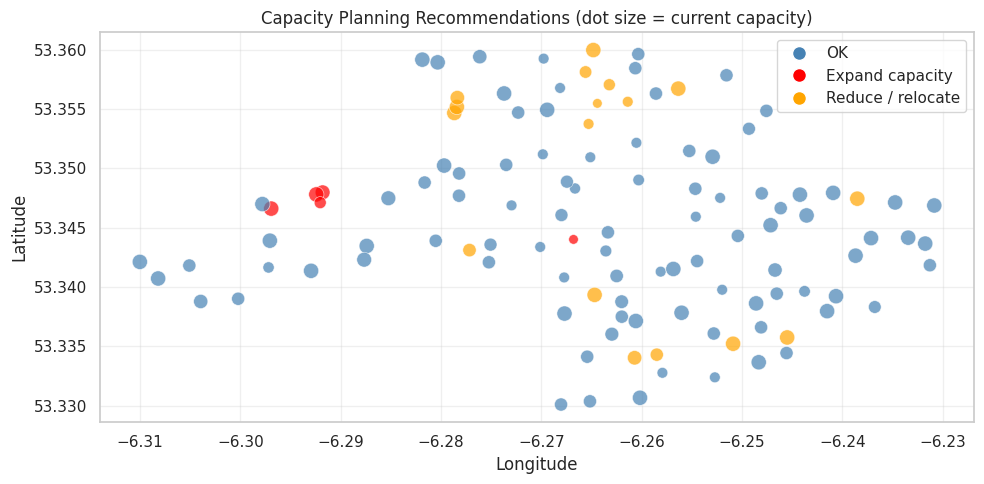

In [89]:
# Stations where utilisation > 80% consistently (need more docks)
# Stations where utilisation < 20% consistently (oversized / candidate for removal)

cap_df = df.copy()
cap_df['overloaded'] = (cap_df['utilisation'] > 0.8).astype(int)
cap_df['underused']  = (cap_df['utilisation'] < 0.2).astype(int)

cap_sta = cap_df.groupby(['station_id','name']).agg(
    capacity       = ('capacity','first'),
    avg_util       = ('utilisation','mean'),
    pct_overloaded = ('overloaded','mean'),
    pct_underused  = ('underused','mean'),
    lat=('lat','first'), lon=('lon','first')
).reset_index()

cap_sta['recommendation'] = 'OK'
cap_sta.loc[cap_sta['pct_overloaded'] > 0.40, 'recommendation'] = 'Expand capacity'
cap_sta.loc[cap_sta['pct_underused']  > 0.60, 'recommendation'] = 'Reduce / relocate'

print('\nCapacity planning summary:')
print(cap_sta['recommendation'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = cap_sta['recommendation'].map({'OK':'steelblue','Expand capacity':'red','Reduce / relocate':'orange'})
ax.scatter(cap_sta['lon'], cap_sta['lat'], c=colors, s=cap_sta['capacity']*3,
           alpha=0.7, edgecolors='white', linewidths=0.5)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',markersize=10,label='OK'),
                   Line2D([0],[0],marker='o',color='w',markerfacecolor='red',markersize=10,label='Expand capacity'),
                   Line2D([0],[0],marker='o',color='w',markerfacecolor='orange',markersize=10,label='Reduce / relocate')]
ax.legend(handles=legend_elements)
ax.set_title('Capacity Planning Recommendations (dot size = current capacity)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

Main Idea: The code studies historical station utilization patterns and classifies stations into.

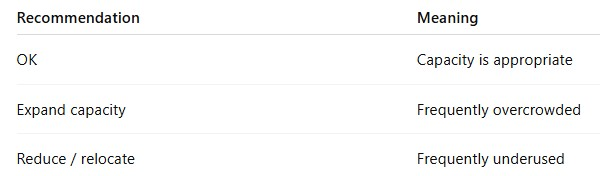

In [90]:
Image(filename='cap.jpg', width = 400, height = 200)

### 9d. Station Uptime Analysis

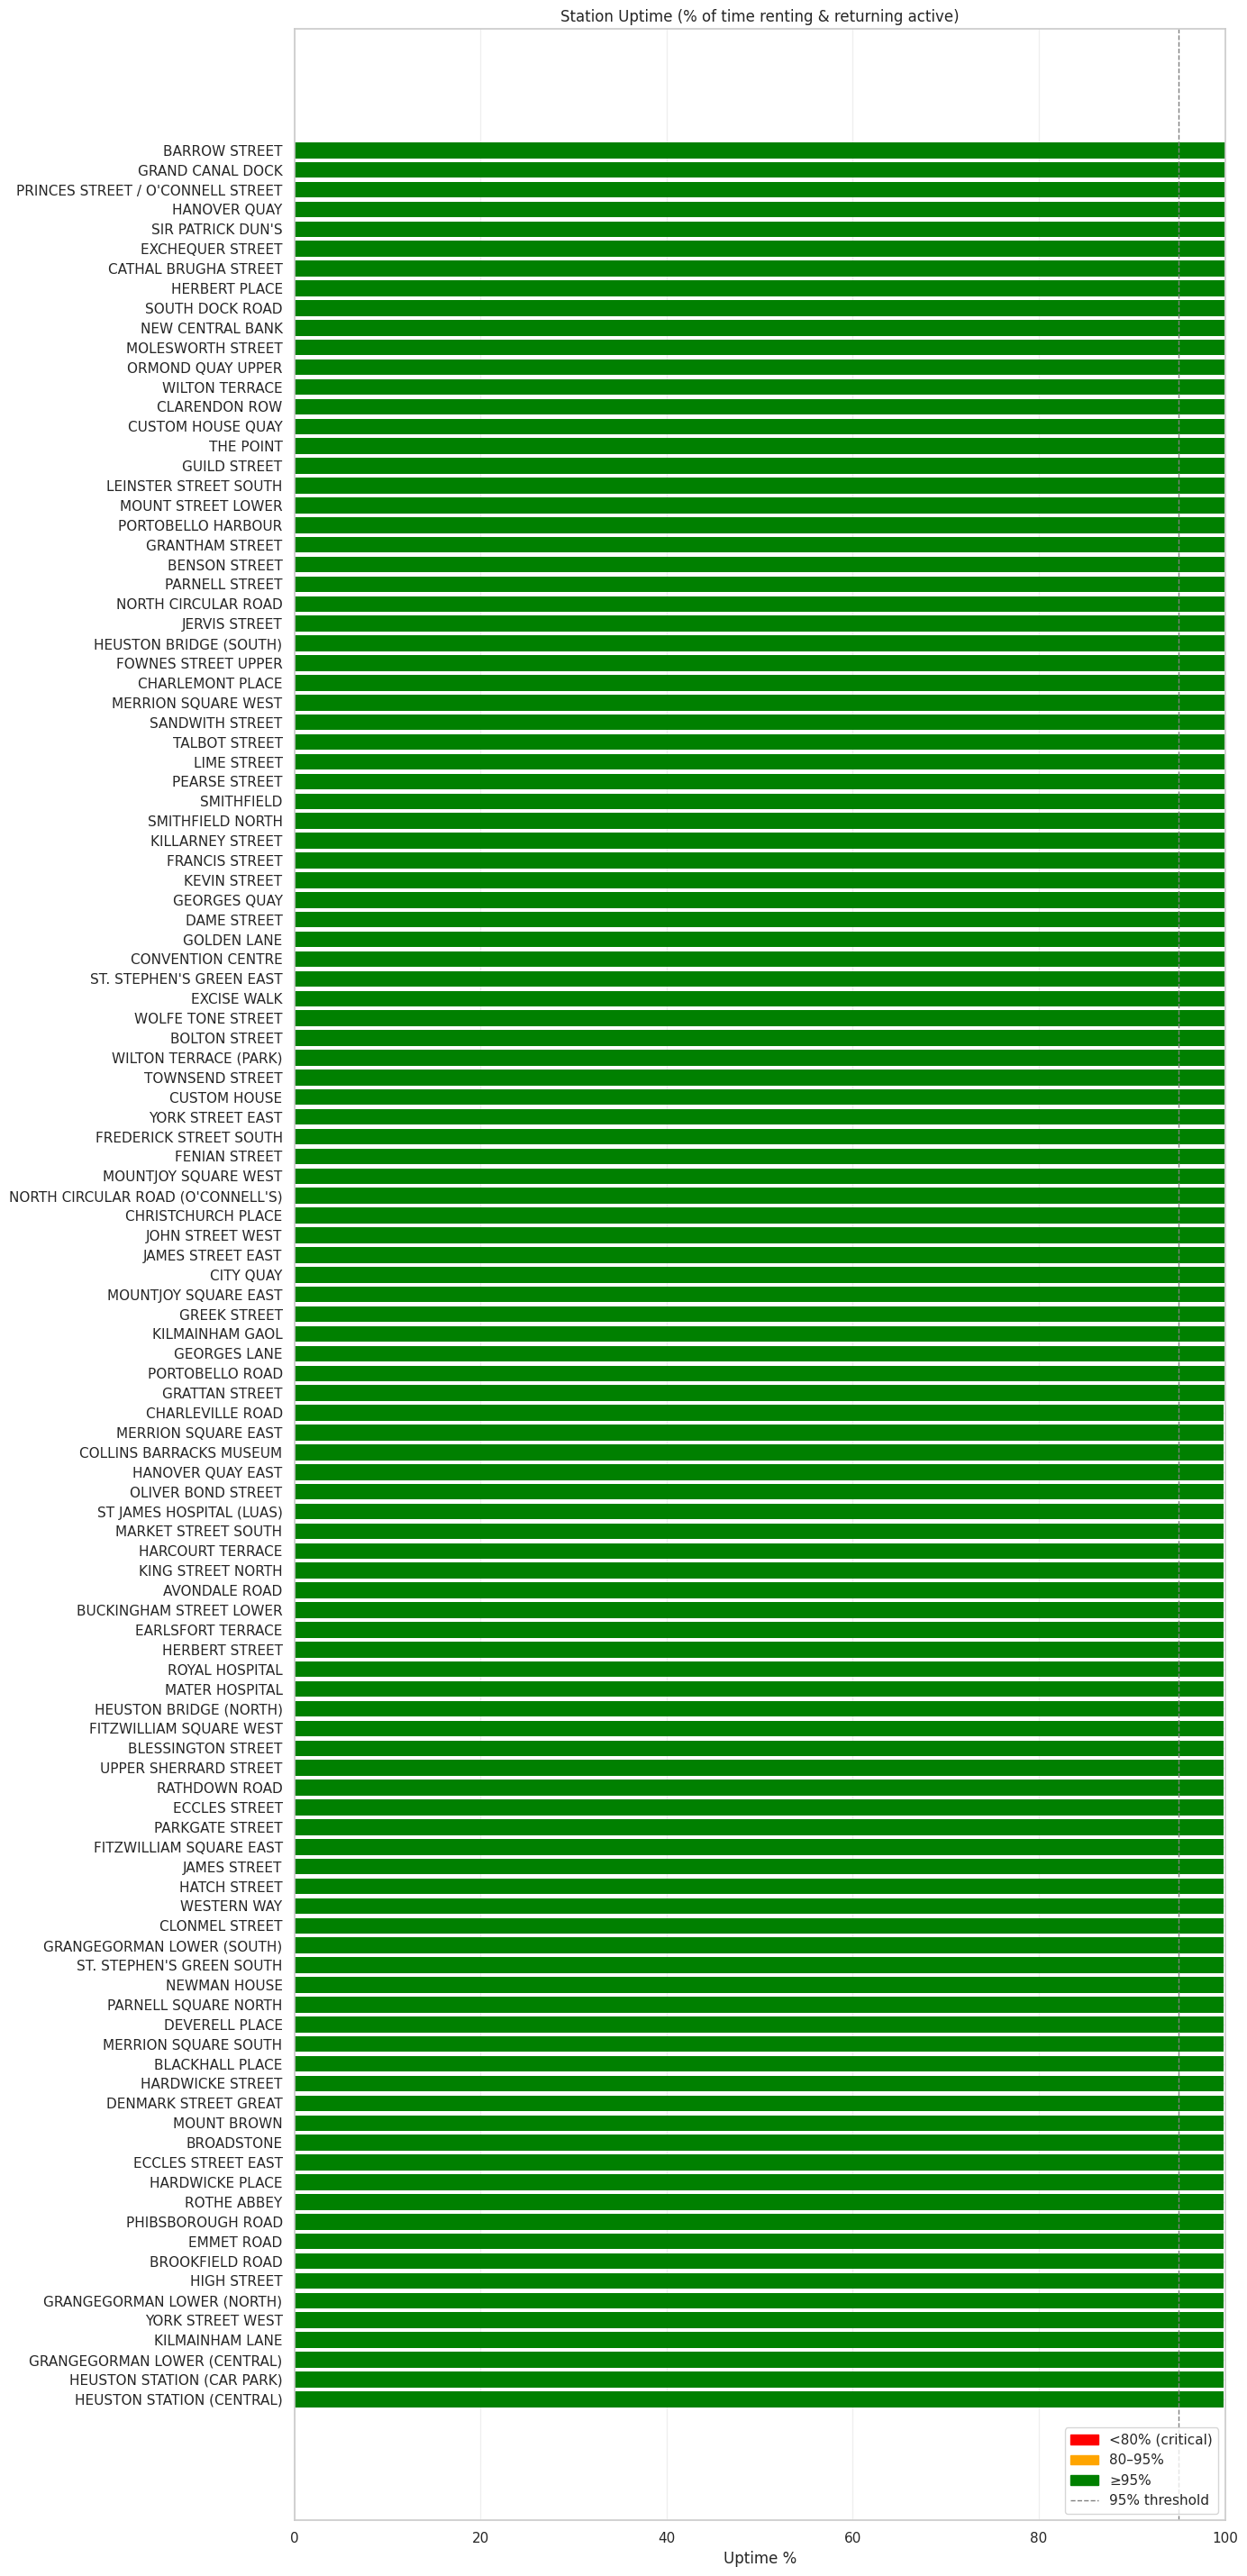

Stations with <80% uptime: 0


In [98]:
import matplotlib.patches as mpatches

uptime = df.groupby('station_id').agg(
    name           = ('name', 'first'),
    total_records  = ('last_reported', 'count'),
    renting_pct    = ('is_renting',   lambda x: x.mean() * 100),
    returning_pct  = ('is_returning', lambda x: x.mean() * 100),
).reset_index()
uptime['uptime_pct'] = (uptime['renting_pct'] + uptime['returning_pct']) / 2

uptime_sorted = uptime.sort_values('uptime_pct')

# Scale figure height to the number of stations so bars/labels stay readable
fig_height = max(5, len(uptime_sorted) * 0.25)
fig, ax = plt.subplots(figsize=(14, fig_height))

colors = uptime_sorted['uptime_pct'].apply(
    lambda x: 'red' if x < 80 else ('orange' if x < 95 else 'green')
)

ax.barh(uptime_sorted['name'], uptime_sorted['uptime_pct'], color=colors, edgecolor='none')
ax.axvline(95, color='gray', linestyle='--', linewidth=1, label='95% threshold')

ax.set_xlim(0, 100)
ax.set_title('Station Uptime (% of time renting & returning active)')
ax.set_xlabel('Uptime %')
ax.grid(axis='x', alpha=0.3)

# Proper legend: threshold line + color meaning (previously only the line had one)
legend_handles = [
    mpatches.Patch(color='red', label='<80% (critical)'),
    mpatches.Patch(color='orange', label='80–95%'),
    mpatches.Patch(color='green', label='≥95%'),
    ax.lines[0],  # the 95% threshold line
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

low_uptime = uptime[uptime['uptime_pct'] < 80].sort_values('uptime_pct')
print(f'Stations with <80% uptime: {len(low_uptime)}')
if not low_uptime.empty:
    print(low_uptime[['station_id', 'name', 'renting_pct', 'returning_pct', 'uptime_pct']].to_string(index=False))

Color-codes stations by health status:

Green-Healthy/High Uptime

Orange-Moderate Issues

Red-Poor Reliability

Identifies stations with uptime below 80%

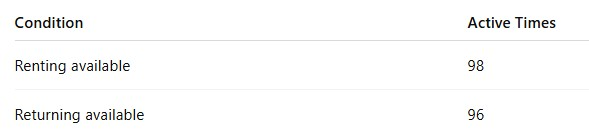

In [92]:
Image(filename='uptime.jpg', width = 400, height = 200)

## 10. Advanced Time Series <a id='10'></a>

### 10a. STL Decomposition

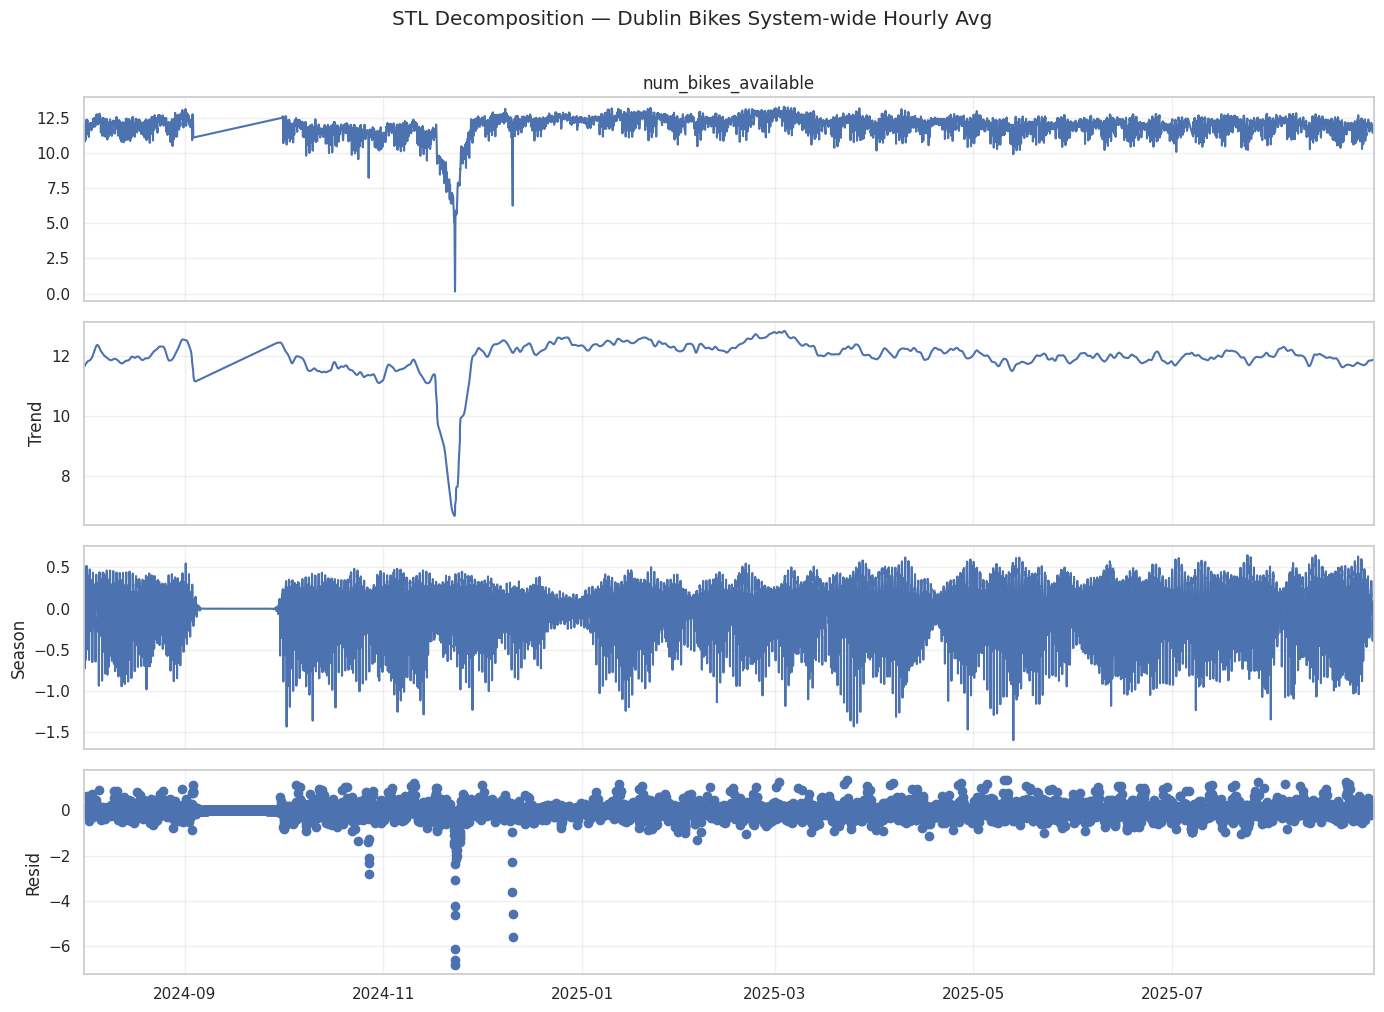

Trend range   : 6.67 → 12.84
Seasonal range: -1.59 → 0.65
Residual std  : 0.282


In [93]:
from statsmodels.tsa.seasonal import STL

# Hourly system-wide average
ts = (df.set_index('last_reported')['num_bikes_available']
        .resample('1h').mean()
        .interpolate('linear')
        .dropna())

# STL with daily period (24 hours)
stl = STL(ts, period=24, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 10)
fig.suptitle('STL Decomposition — Dublin Bikes System-wide Hourly Avg', y=1.01)
plt.tight_layout(); plt.show()

print(f'Trend range   : {res.trend.min():.2f} → {res.trend.max():.2f}')
print(f'Seasonal range: {res.seasonal.min():.2f} → {res.seasonal.max():.2f}')
print(f'Residual std  : {res.resid.std():.3f}')

## 10. Monte Carlo Simulation <a id='11'></a>

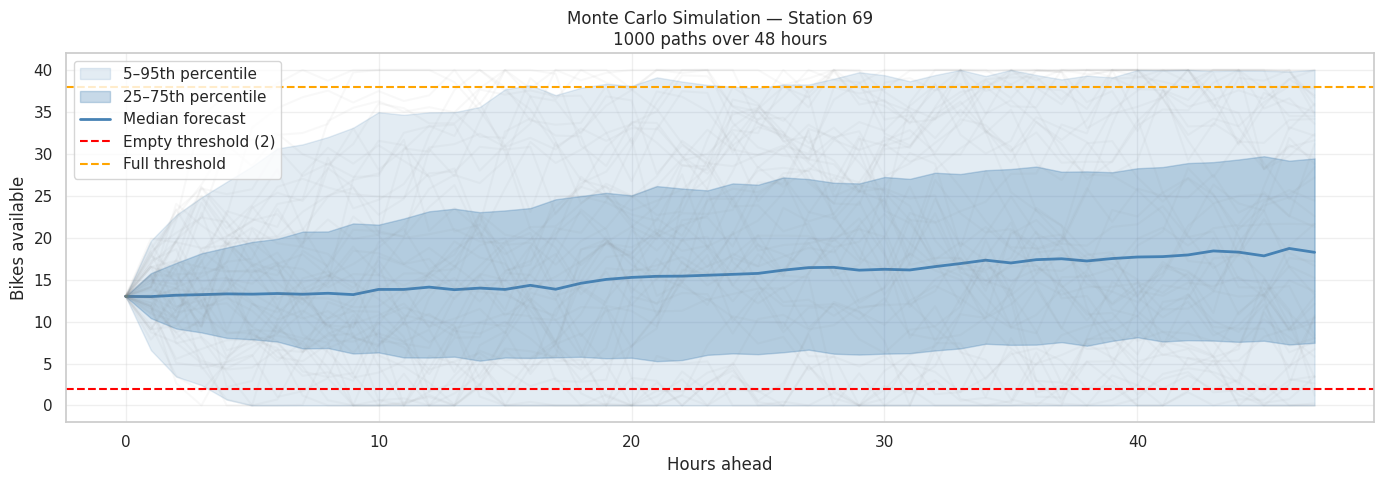

Probability station goes empty within 48h : 62.4%
Probability station goes full  within 48h : 35.3%


In [95]:
# Simulate future availability for a station under different demand scenarios
np.random.seed(42)

MC_STATION = df['station_id'].value_counts().index[0]
mc_data = df[df['station_id'] == MC_STATION].sort_values('last_reported')

# Estimate hourly change distribution from historical data
mc_hourly = (mc_data.set_index('last_reported')['num_bikes_available']
                    .resample('1h').mean().interpolate())
hourly_changes = mc_hourly.diff().dropna()
mu    = hourly_changes.mean()
sigma = hourly_changes.std()

start_val = mc_hourly.iloc[-1]  # last known value
capacity  = int(mc_data['capacity'].iloc[0])

N_SIM    = 1000
N_HOURS  = 48    # simulate 48 hours ahead

simulations = np.zeros((N_SIM, N_HOURS))
for i in range(N_SIM):
    path = [start_val]
    for _ in range(N_HOURS - 1):
        delta = np.random.normal(mu, sigma)
        next_val = np.clip(path[-1] + delta, 0, capacity)
        path.append(next_val)
    simulations[i] = path

p5  = np.percentile(simulations, 5,  axis=0)
p25 = np.percentile(simulations, 25, axis=0)
p50 = np.percentile(simulations, 50, axis=0)
p75 = np.percentile(simulations, 75, axis=0)
p95 = np.percentile(simulations, 95, axis=0)

hours = range(N_HOURS)
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(hours, p5,  p95, alpha=0.15, color='steelblue', label='5–95th percentile')
ax.fill_between(hours, p25, p75, alpha=0.30, color='steelblue', label='25–75th percentile')
ax.plot(hours, p50, color='steelblue', linewidth=2, label='Median forecast')
# Plot a sample of individual paths
for i in range(50):
    ax.plot(hours, simulations[i], alpha=0.05, color='gray')
ax.axhline(EMPTY_THRESH, color='red',  linestyle='--', label=f'Empty threshold ({EMPTY_THRESH})')
ax.axhline(capacity - FULL_THRESH, color='orange', linestyle='--', label='Full threshold')
ax.set_title(f'Monte Carlo Simulation — Station {MC_STATION}\n{N_SIM} paths over 48 hours')
ax.set_xlabel('Hours ahead'); ax.set_ylabel('Bikes available')
ax.legend()
plt.tight_layout(); plt.show()

prob_empty = (simulations <= EMPTY_THRESH).any(axis=1).mean() * 100
prob_full  = (simulations >= capacity - FULL_THRESH).any(axis=1).mean() * 100
print(f'Probability station goes empty within 48h : {prob_empty:.1f}%')
print(f'Probability station goes full  within 48h : {prob_full:.1f}%')

## Summary

| Section | Technique | Key Output |
|---------|-----------|------------|
| Short-term forecasting | XGBoost + lag features | MAE/RMSE for 15/30/60 min horizons |
| Peak-hour prediction | Aggregation + heatmap | Busiest stations during rush hours |
| Long-term trends | Rolling MA + box plots | Seasonal & weekday/weekend patterns |
| Empty/full risk | LightGBM classifier | AUC, precision/recall per station |
| Station clustering | K-Means + Silhouette | Residential/office/tourist clusters + Folium map |
| Temporal clustering | Agglomerative + dendrogram | Hourly profile clusters |
| Demand heatmaps | Folium HeatMap | Morning/evening hot zones |
| Anomaly detection | Z-score + Isolation Forest | Demand spikes & malfunctions |
| Next-station recommender | Haversine distance | Nearest bike/dock in real time |
| Geospatial coverage | Voronoi diagram | Coverage gaps in city |
| Utilisation analysis | Station-level KPIs | Over/under-utilised stations |
| Rebalancing | Surplus/deficit model | Which stations need bikes moved |
| Capacity planning | Threshold analysis | Stations needing expansion/reduction |
| Uptime analysis | Operational flags | Stations with low uptime |
| STL decomposition | statsmodels STL | Trend + seasonal + residual |
| Monte Carlo simulation | Stochastic path simulation | Probability of empty/full within 48h |